# Quantum Acrobatics  (Fillable)

In [1]:
import pennylane as qml
from pennylane import numpy as np
from pennylane.operation import Operation
import random

In [4]:
# Two qubit device 
dev = qml.device('default.qubit', wires=2)

### Task 1: Identity or Pauli-$X$
Input: An operation that implements a single-qubit unitary transformation: either the identity ($I$ gate) or the Pauli-$X$ gate. 
$$
I = \begin{bmatrix}
1 & 0 \\
0 & 1
\end{bmatrix} X = \begin{bmatrix}
0 & 1 \\
1 & 0
\end{bmatrix}
$$
Output: $0$ if the given operation is the $I$ gate, $1$ if the given operation is the Pauli-$X$ gate.

You are allowed to apply the given operation and its adjoint or controlled variant exactly once.


In [2]:
def mysteryU1():
    if (random.randint(0, 1)):
        return np.array([[1, 0], [0, 1]])
    else:
        return np.array([[0, 1], [1, 0]])

In [13]:
@qml.qnode(dev)
def task1():
    U  = mysteryU1() # apply the unitary on |0>. 
    print(U)
    qml.QubitUnitary(U, wires=0)
    return qml.probs(op=qml.PauliZ(0))

In [20]:
task1()


[[1 0]
 [0 1]]


tensor([1., 0.], requires_grad=True)

## Task 1.2. Identity or Pauli Z?

**Input:** An operation that implements a single-qubit unitary transformation:
either the identity (**I** gate)
or the Pauli Z gate (**Z** gate). 
The operation will have Adjoint and Controlled variants defined.

**Output:**  0 if the given operation is the **I** gate, 1 if the given operation is the **Z** gate.

You are allowed to apply the given operation and its adjoint/controlled variants exactly **once**.

In [21]:
def mysteryU2():
    if (random.randint(0, 1)):
        return np.array([[1, 0], [0, 1]])
    else:
        return np.array([[1, 0], [0, -1]])

In [42]:
@qml.qnode(dev)
def task2():
    U  = mysteryU2()
    print(U)
    # Your code

    # we cannot apply the unitary on |0>. this would have no effect on the global phase. 
    # if we put it on |1>, we would not change our measurement probabilities -- measurement destroys relative phase. 

    # therefore we MUST put the qubit into equal superpositon via H gate. 

    qml.H(wires=0) # H|0> = |+>. 
    qml.QubitUnitary(U, wires=0) # apply the unitary. 

    # U||+> yields: 
    #   1. |+> (we applied I)
    #   2. |->  (we applied Z)

    # we need to apply another hadamard gate to get a deterministic state. 

    qml.H(wires=0)

    return qml.probs(op=qml.PauliZ(0)) # measure out in computational basis. 


In [47]:
task2()

[[ 1  0]
 [ 0 -1]]


tensor([0., 1.], requires_grad=True)

### Task 1.3. Z or S?

**Input:** An operation that implements a single-qubit unitary transformation:
either the **Z** gate
or the **S** gate. 
The operation will have Adjoint and Controlled variants defined.

**Output:**  0 if the given operation is the **Z** gate, 1 if the given operation is the **S** gate.

You are allowed to apply the given operation and its adjoint/controlled variants at most **twice**.

In [50]:
def mysteryU3():
    if (random.randint(0, 1)):
        return np.array([[1, 0], [0, -1]])
    else:
        return np.array([[1, 0], [0, 1j]])

In [ ]:
@qml.qnode(dev)
def task3():
    U  = mysteryU3()
    print(U)
    # Your code

    # put it into superposition via H.

    qml.H(wires=0)

    # if we get Z, we apply a relative phase change of pi. 
    # if we get S, we apply a relative phase change of pi/2. 

    # therefore we want to apply the unitary twice - if we Z, the relative phase is eliminated (as it is a factor of 2*pi), but if we have S, we introduce a relative phase of pi. 


    # apply the unitary twice
    qml.QubitUnitary(U, wires=0)
    qml.QubitUnitary(U, wires=0)

    # check the relative phase by going back out of Hadamard basis. 
    # observe that the relative phase will change: UU|+> yields: 
    #   1. UU|+> = |+> implies U == Z. 
    #   2. UU|+> = |-> implies U == S. 

    qml.H(wires=0)
 

    
    return qml.probs(op=qml.PauliZ(0))

In [58]:
task3()

[[ 1  0]
 [ 0 -1]]


tensor([1., 0.], requires_grad=True)

### Task 1.4. Hadamard or X?

**Input:** An operation that implements a single-qubit unitary transformation:
either the Hadamard (**H**) gate
or the **X** gate. 
The operation will have Adjoint and Controlled variants defined.

**Output:**  0 if the given operation is the **H** gate, 1 if the given operation is the **X** gate.

You are allowed to apply the given operation and its adjoint/controlled variants at most **twice**.

In [88]:
def mysteryU4():
    if (random.randint(0, 1)):
        return np.array([[1/np.sqrt(2), 1/np.sqrt(2)], [1/np.sqrt(2), -1/np.sqrt(2)]])
    else:
        return np.array([[0, 1], [1, 0]])

In [ ]:
@qml.qnode(dev)
def task4():
    U  = mysteryU4()
    print(U)
    # Your code

    """

    U|0> yields: 
        1. U|0> = |1> implies U = X
        2. U|0> = |+> implies U = H. (but this is unhelpful, as we are in a superposition). 

        Therefore, we apply X. 
    XU|0> yields:
        1. XU|0> = |0> implies U = X
        2. XU|0> = |+> implies U = H 

    We apply U again: 
        1. UXU|0> = |1> implies U = X
        2. UXU|0> = |0> implies U = H
    
    We can now measure in the Z basis. 

    """
    
    return 

In [121]:
task4()

[[0 1]
 [1 0]]


tensor([0., 1.], requires_grad=True)

### Task 1.5. Z or $-$Z?

**Input:** An operation that implements a single-qubit unitary transformation:
either the **Z** gate
or the minus **Z** gate (i.e., the gate $- |0\rangle\langle0| + |1\rangle\langle1|$). 
The operation will have Adjoint and Controlled variants defined.

**Output:**  0 if the given operation is the **Z** gate, 1 if the given operation is the $-$**Z** gate.

You are allowed to apply the given operation and its adjoint/controlled variants exactly **once**.

In [146]:
def mysteryU5():
    if (random.randint(0, 1)):
        return np.array([[1, 0], [0, -1]])
    else:
        return np.array([[-1, 0], [0, 1]])

In [ ]:
@qml.qnode(dev)
def task5():
    U  = mysteryU5()
    print(U)
    # Your code
    
    """

    Since this deals with distinguishing global phase, we need to use phase kickback. 
    
    Therefore, we turn U into a controlled unitary operator. 

    To do this, we put q0 into H basis, and keep q1 in the Z basis. 

    This yields: 

    (H KRON I) |00> = |+0> 

    We apply our controlled unitary: 

    (Control-U) |+0> yields: 
        1. 1/sqrt(2) * (|00> + |10>) implies U =  Z. [Recall Z|0> = |0>, Z|1> = -|1>]
        2. 1/sqrt(2) * (|00> - |10>) implies U = -Z. [Recall -Z|0> = -|0> , -Z|1> = --|1> = |1>].

        
    We can then decompose the state into distinct qubits: 
        1. (|00> + |10>) = |+> \otimes |0>
        2. (|00> - |10>) = |-> \otimes |0> 

    We can then apply hadamard to the first qubit: 
        1. (H KRON I) (|00> + |10>) = |0> \otimes |0>
        2. (H KRON I) (|00> - |10>) = |1> \otimes |0> 

    We can then measure out the first qubit: 
        1. If we obtain |0>, we know U =  Z. 
        2. If we obtain |1>, we know U = -Z. 
    """


    return 

[[-1  0]
 [ 0  1]]


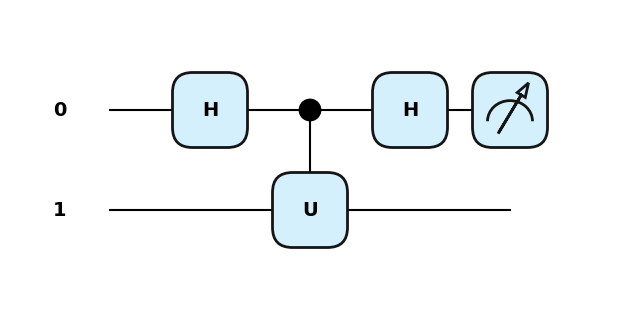

In [161]:
_ = qml.draw_mpl(task5, style="pennylane")()

In [175]:
task5()

[[ 1  0]
 [ 0 -1]]


tensor([1., 0.], requires_grad=True)

### Task 6. $R_Z$ or PhaseShift($R_\phi$) ?

**Input:** An operation that implements a single-qubit unitary transformation:
either the [$R_Z$ gate](https://docs.pennylane.ai/en/stable/code/api/pennylane.RZ.html)
or the [$R_\phi$ gate](https://docs.pennylane.ai/en/stable/code/api/pennylane.PhaseShift.html). 

This operation will take two parameters: the first parameter is the rotation angle, in radians, and the second parameter is the wires to which the gate should be applied.

**Output:**  0 if the given operation is the $R_Z$ gate, 1 if the given operation is the $R_\phi$ gate.

You are allowed to apply the given operation and its adjoint/controlled variants exactly **once**.

In [177]:
def mysteryU6(phi):
    if (random.randint(0, 1)):
        return qml.RZ.compute_matrix(phi)
    else:
        return qml.PhaseShift.compute_matrix(phi)

In [178]:
@qml.qnode(dev)
def task6():
    phi = 2*np.pi
    U  = mysteryU6(phi)
    print(U)
    # Your code
    
    return 

In [188]:
task6()

[[1.+0.0000000e+00j 0.+0.0000000e+00j]
 [0.+0.0000000e+00j 1.-2.4492936e-16j]]


array([1., 0.])